# Exploratory Data Analysis on Retail Sales

## Project Overview

This project performs exploratory data analysis on a retail sales dataset to identify sales trends, customer demographics, product-category performance, and relationships between numerical variables.

### Objectives

- Analyze monthly and quarterly sales trends.
- Understand customer demographics based on gender and age groups.
- Analyze sales performance across product categories.
- Examine the relationship between numerical variables.
- Identify important business insights.
- Provide actionable recommendations based on the analysis.





In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Inspection

In [93]:
df = pd.read_csv('/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [95]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


## 2. Data Cleaning and Validation

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df['Date'] = pd.to_datetime(df['Date'])

In [98]:
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


## 3. Descriptive Statistics

In [99]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [100]:
stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Standard Deviation': df.std(numeric_only=True)
})
stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## 4. Sales Trend Analysis

In [101]:
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

In [102]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


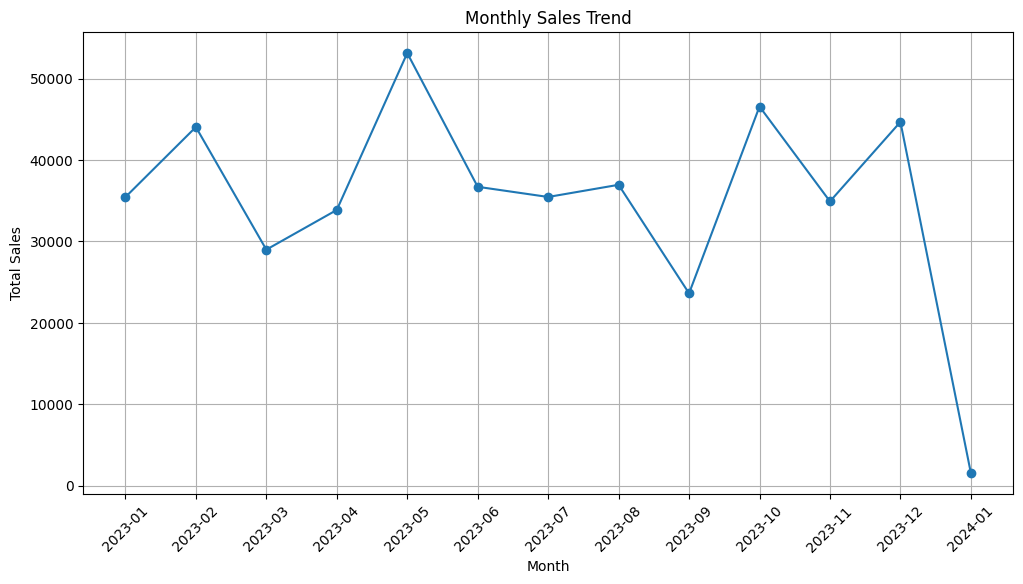

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [104]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales

,Total Amount
Quarter,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


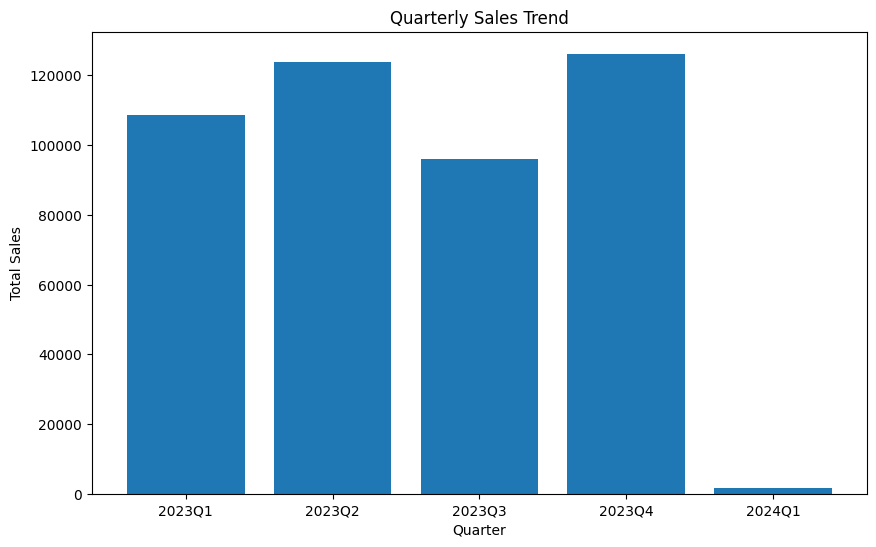

In [105]:
plt.figure(figsize=(10, 6))
plt.bar(quarterly_sales.index.astype(str), quarterly_sales.values)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

### Sales Trend Observations

- Monthly sales show noticeable fluctuations throughout 2023, with May recording one of the highest sales values.
- September recorded a relatively low sales value compared with the surrounding months.
- Sales recovered during the final quarter of 2023, with October and December showing strong performance.
- Q4 2023 recorded the highest quarterly sales among the complete quarters in the dataset.
- Q3 2023 recorded the lowest quarterly sales among the complete quarters of 2023.
- January 2024 shows a sharp decline in sales; however, this should be interpreted cautiously because the dataset contains only partial data for 2024.

## 5. Customer Demographic Analysis

In [106]:
gender_counts = df['Gender'].value_counts()
gender_counts

,count
Gender,
Female,510
Male,490


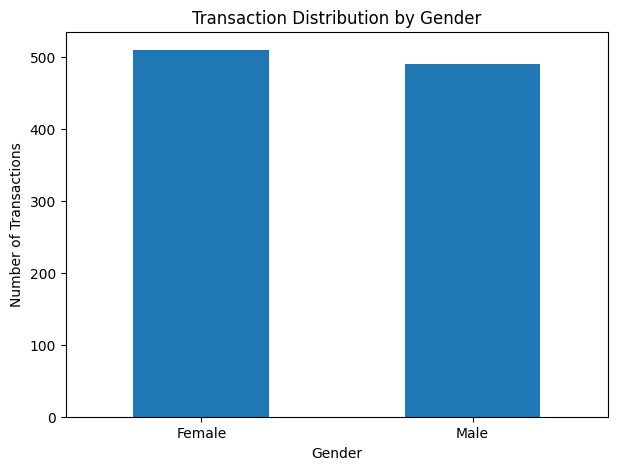

In [107]:
gender_counts.plot(
    kind='bar',
    figsize=(7, 5)
)
plt.title('Transaction Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

In [108]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


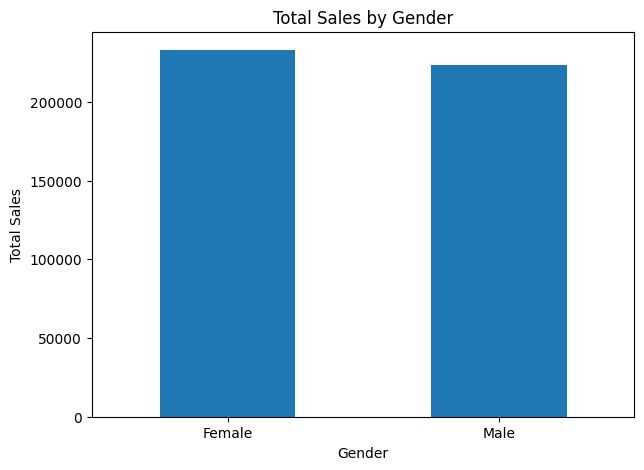

In [109]:
gender_sales.plot(
    kind='bar',
    figsize=(7, 5)
)
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Gender Analysis

- Female customers accounted for 510 transactions (51%), while male customers accounted for 490 transactions (49%).
- Female customers generated total sales of 232,840, representing approximately 51.1% of overall sales.
- Male customers generated total sales of 223,160, representing approximately 48.9% of overall sales.
- The average transaction value is very similar for both genders, indicating that purchasing value is relatively balanced between male and female customers.

In [110]:
bins = [0, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)
df[['Age', 'Age Group']].head()

,Age,Age Group
0,34,26-35
1,26,26-35
2,50,46-55
3,37,36-45
4,30,26-35


In [111]:
age_group_counts = df['Age Group'].value_counts().sort_index()
age_group_counts

,count
Age Group,
18-25,169
26-35,205
36-45,202
46-55,229
56+,195


In [112]:
age_group_sales = df.groupby(
    'Age Group',
    observed=True
)['Total Amount'].sum()
age_group_sales

,Total Amount
Age Group,
18-25,84550
26-35,98480
36-45,91870
46-55,100690
56+,80410


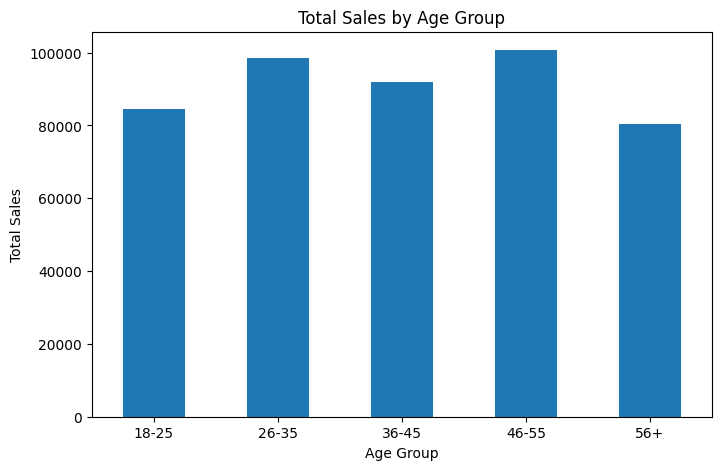

In [113]:
age_group_sales.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Age Group Analysis

- Customers aged 46–55 generated the highest total sales of 100,690, contributing approximately 22.1% of overall revenue.
- The 26–35 age group was the second-highest contributor, generating 98,480 in sales.
- Customers aged 56 and above generated the lowest sales at 80,410, representing approximately 17.6% of total revenue.
- Overall, sales are relatively evenly distributed across the age groups, with each group contributing a similar share of total revenue.

## 6. Product Category Analysis

In [114]:
category_sales= df.groupby('Product Category')['Total Amount'].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


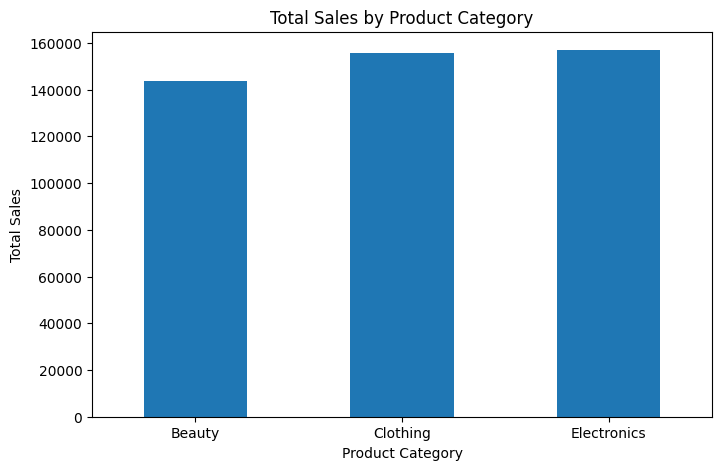

In [115]:
category_sales.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [116]:
category_quantity = df.groupby('Product Category')['Quantity'].sum()
category_quantity

,Quantity
Product Category,
Beauty,771
Clothing,894
Electronics,849


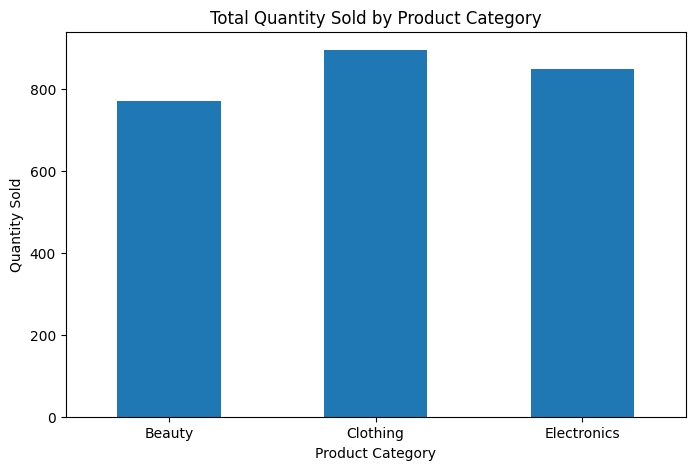

In [117]:
category_quantity.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.show()

### Product Category Observations

- Clothing recorded the highest quantity sold, with 894 units.
- Electronics generated the highest total revenue at 156,905, despite selling fewer units than Clothing.
- Beauty recorded the lowest quantity sold at 771 units and the lowest total revenue at 143,515.
- Electronics generated more revenue than Clothing even though its total quantity sold was lower, indicating a higher average revenue contribution per unit.
- Overall, Clothing has the strongest sales volume, while Electronics has the strongest revenue performance.

In [118]:
top_transactions = df.nlargest(10, 'Total Amount')
top_transactions[
    ['Transaction ID', 'Date', 'Customer ID',
     'Gender', 'Age', 'Product Category',
     'Quantity', 'Price per Unit', 'Total Amount']
]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
64,65,2023-12-05,CUST065,Male,51,Electronics,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
73,74,2023-11-22,CUST074,Female,18,Beauty,4,500,2000
88,89,2023-10-01,CUST089,Female,55,Electronics,4,500,2000
92,93,2023-07-14,CUST093,Female,35,Beauty,4,500,2000
108,109,2023-10-18,CUST109,Female,34,Electronics,4,500,2000
117,118,2023-05-16,CUST118,Female,30,Electronics,4,500,2000
123,124,2023-10-27,CUST124,Male,33,Clothing,4,500,2000
138,139,2023-12-15,CUST139,Male,36,Beauty,4,500,2000


In [119]:
top_category_counts = top_transactions['Product Category'].value_counts()
top_category_counts

,count
Product Category,
Electronics,6
Beauty,3
Clothing,1


### Top Transaction Analysis

- Electronics appeared in 6 of the 10 highest-value transactions, making it the most represented category among high-value purchases.
- Beauty appeared in 3 of the top 10 transactions, while Clothing appeared in only 1.
- The strong representation of Electronics among high-value transactions is consistent with its position as the highest-revenue product category overall.
- The dataset does not contain individual product names, so product-level top-selling analysis cannot be performed. Therefore, the analysis is limited to product-category performance.

## 7. Correlation Analysis

In [120]:
correlation_matrix = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()
correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


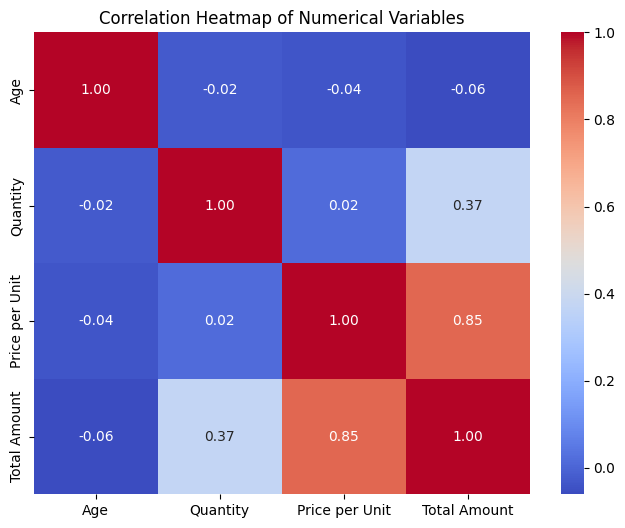

In [121]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Correlation Analysis

- Price per Unit has the strongest positive correlation with Total Amount (0.85), indicating that higher-priced products contribute significantly to higher transaction values.
- Quantity has a moderate positive correlation with Total Amount (0.37), suggesting that purchasing more items generally increases sales revenue.
- Quantity and Price per Unit show almost no correlation (0.02), indicating that customers buying more items are not necessarily purchasing expensive products.
- Age has a very weak correlation with Quantity (-0.02), Price per Unit (-0.04), and Total Amount (-0.06), suggesting that age has little influence on purchasing behavior in this dataset.

## 8. Transaction Amount Distribution

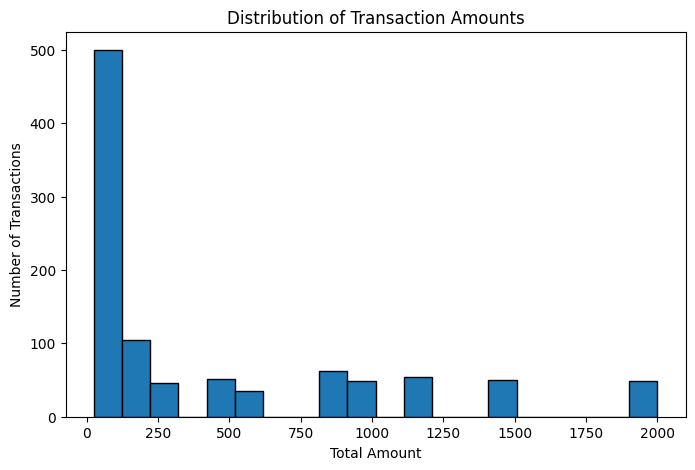

In [122]:
plt.figure(figsize=(8, 5))
plt.hist(df['Total Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Total Amount')
plt.ylabel('Number of Transactions')
plt.show()

### Transaction Amount Distribution

- The histogram shows a strongly right-skewed distribution of transaction amounts.
- Most transactions are concentrated in the lower total-amount range.
- Only a smaller number of transactions have high transaction values, extending up to approximately 2,000.
- This indicates that the dataset contains many low-value purchases along with a smaller number of high-value transactions.
- The presence of high-value transactions is consistent with the strong positive correlation between Price per Unit and Total Amount.

# Business Insights and Recommendations

1.   List item
2.   List item



## Key Business Insights

1. **Q4 2023 recorded the highest quarterly sales**
   - Q4 2023 generated approximately 128,000 in sales, making it the strongest complete quarter in the dataset.
   - Q3 2023 recorded the lowest sales among the complete quarters at approximately 96,000.

2. **Female customers contributed slightly more revenue**
   - Female customers accounted for 510 transactions (51%), while male customers accounted for 490 transactions (49%).
   - Female customers generated 232,840 in total sales compared with 223,160 from male customers.
   - Revenue contribution is therefore relatively balanced between the two genders.

3. **Customers aged 46–55 generated the highest revenue**
   - The 46–55 age group generated the highest sales at 100,690.
   - Customers aged 56 and above generated the lowest sales at 80,410.
   - However, sales are relatively evenly distributed across all age groups.

4. **Electronics was the highest-revenue product category**
   - Electronics generated 156,905 in sales, slightly ahead of Clothing at 155,580.
   - Beauty generated the lowest category revenue at 143,515.
   - Electronics also appeared in 6 of the 10 highest-value transactions.

5. **Clothing had the highest sales volume**
   - Clothing recorded the highest quantity sold at 894 units.
   - Electronics sold 849 units but generated the highest overall revenue.
   - This indicates that revenue performance and sales volume do not always follow the same pattern.

6. **Product price strongly influences transaction value**
   - Price per Unit had a strong positive correlation of 0.85 with Total Amount.
   - Quantity had a moderate positive correlation of 0.37 with Total Amount.
   - Age showed very weak correlations with Total Amount, Quantity, and Price per Unit, suggesting that age has little linear relationship with purchasing behavior in this dataset.

7. **Most transactions are relatively low-value**
   - The transaction-value histogram shows a strongly right-skewed distribution.
   - Most transactions are concentrated at lower values, while a smaller number of transactions have much higher values.
   


## Actionable Recommendations

1. **Focus promotional campaigns on high-performing periods**
   - Analyze the factors behind the strong Q4 2023 performance and consider similar promotional campaigns, offers, and product strategies during future high-demand periods.

2. **Strengthen the Electronics category**
   - Electronics generated the highest revenue and appeared frequently among high-value transactions.
   - The business can focus on targeted promotions, product bundles, and cross-selling opportunities within this category.

3. **Increase average transaction value**
   - Since Price per Unit has a strong positive correlation with Total Amount, the business can promote premium products and suitable product bundles.
   - Cross-selling and upselling can also be used to increase the value of individual transactions.


## Conclusion

The exploratory data analysis provided useful insights into the company's sales trends, customer demographics, and product-category performance. Electronics was the highest-revenue category, Clothing had the highest sales volume, and customers aged 46–55 contributed the most revenue. Sales were strongest in Q4 2023, while transaction values were strongly influenced by product price. These findings can help the business improve promotional planning, strengthen high-performing categories, and increase transaction value through targeted sales strategies.
